# CH 6 : Data-Mining Bias as a Function of Number of Observations

## Objectif pédagogique

Ce notebook illustre une idée centrale d’**Evidence-Based Technical Analysis** de David Aronson :

> Plus le nombre d’observations augmente, plus la performance observée d’une règle converge vers son mérite réel.

Dans cette section, on se place dans un univers de **mérite variable** : certaines règles ont réellement une meilleure espérance que d’autres, mais le hasard peut temporairement faire passer une règle médiocre pour une règle exceptionnelle.

L’objectif est de comprendre pourquoi un backtest court est dangereux, surtout lorsqu’on teste beaucoup de règles.

## 1. Le problème EBTA

En trading algorithmique, on ne teste rarement qu’une seule idée.

On teste souvent :

- plusieurs indicateurs ;
- plusieurs paramètres ;
- plusieurs timeframes ;
- plusieurs règles d’entrée ;
- plusieurs règles de sortie ;
- plusieurs filtres de volatilité ou de tendance.

Chaque test ajoute une opportunité pour le hasard de produire un résultat flatteur.

Le **biais de minage de données** apparaît quand on sélectionne la meilleure règle observée sur le passé et qu’on confond cette performance sélectionnée avec son véritable pouvoir prédictif.

On peut résumer la performance observée ainsi :

$$
P_{obs} = P_{réel} + H
$$

où :

- $P_{obs}$ est la performance mesurée dans le backtest ;
- $P_{réel}$ est le mérite réel de la règle ;
- $H$ est la contribution du hasard.

Sur un petit échantillon, $H$ peut dominer $P_{réel}$.

Sur un grand échantillon, $H$ se dilue.

## 2. L’idée mathématique : la Loi des Grands Nombres

La Loi des Grands Nombres dit que plus le nombre d’observations augmente, plus la moyenne observée converge vers l’espérance réelle.

Si une règle a une espérance mensuelle réelle $\mu$, alors sa moyenne observée sur $n$ mois tend vers $\mu$ quand $n$ augmente :

$$
\bar{R}_n \rightarrow \mu
$$

La dispersion de la moyenne observée diminue approximativement comme :

$$
\text{Erreur standard} = \frac{\sigma}{\sqrt{n}}
$$

Donc quand $n$ augmente, la zone dans laquelle le hasard peut déformer la performance se réduit.

> Le temps est le filtre qui sépare le mérite réel de l’illusion statistique.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_data_mining_bias(
    n_observations: int,
    n_rules: int,
    n_experiments: int = 5000,
    merit_mean: float = 0.002,
    merit_std: float = 0.004,
    noise_std: float = 0.04
) -> pd.DataFrame:
    """
    Simule le biais de minage de données dans un univers de mérite variable.

    Chaque expérience représente une recherche de stratégie :
    - on génère n_rules règles ;
    - chaque règle a un mérite réel différent ;
    - on observe sa performance sur n_observations périodes ;
    - on sélectionne la règle avec la meilleure performance observée ;
    - on mesure l'écart entre sa performance observée et son mérite réel.

    Le biais est défini comme :

    observed_best_performance - true_merit_of_selected_rule
    """

    true_merits = np.random.normal(
        loc=merit_mean,
        scale=merit_std,
        size=(n_experiments, n_rules)
    )

    observed_noise = np.random.normal(
        loc=0,
        scale=noise_std / np.sqrt(n_observations),
        size=(n_experiments, n_rules)
    )

    observed_performance = true_merits + observed_noise

    selected_idx = np.argmax(observed_performance, axis=1)

    selected_observed = observed_performance[
        np.arange(n_experiments),
        selected_idx
    ]

    selected_true_merit = true_merits[
        np.arange(n_experiments),
        selected_idx
    ]

    bias = selected_observed - selected_true_merit

    return pd.DataFrame({
        "n_observations": n_observations,
        "n_rules": n_rules,
        "selected_observed": selected_observed,
        "selected_true_merit": selected_true_merit,
        "data_mining_bias": bias
    })

## 3. Exemple simple : même univers, nombre d’observations différent

On garde le même nombre de règles testées, mais on change la taille de l’historique.

L’objectif est de voir ce qui arrive au biais quand on passe de :

- 12 observations ;
- 60 observations ;
- 200 observations ;
- 1 000 observations.

In [2]:
n_rules = 100
observation_grid = [12, 60, 200, 1000]

results = pd.concat([
    simulate_data_mining_bias(n_observations=n, n_rules=n_rules)
    for n in observation_grid
], ignore_index=True)

summary = (
    results
    .groupby("n_observations")
    .agg(
        mean_selected_observed=("selected_observed", "mean"),
        mean_selected_true_merit=("selected_true_merit", "mean"),
        mean_bias=("data_mining_bias", "mean"),
        median_bias=("data_mining_bias", "median"),
        p95_bias=("data_mining_bias", lambda x: np.quantile(x, 0.95))
    )
    .reset_index()
)

summary

,n_observations,mean_selected_observed,mean_selected_true_merit,mean_bias,median_bias,p95_bias
0,12,0.032591,0.005261,0.027330,0.027057,0.037464
1,60,0.018423,0.008181,0.010242,0.010230,0.016211
2,200,0.014284,0.010228,0.004057,0.004050,0.008022
3,1000,0.012497,0.011524,0.000973,0.000969,0.002984


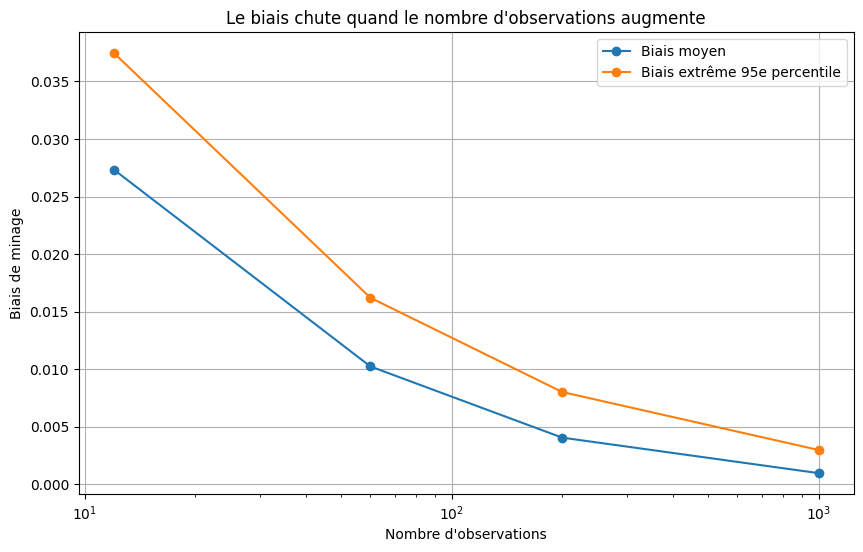

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    summary["n_observations"],
    summary["mean_bias"],
    marker="o",
    label="Biais moyen"
)

plt.plot(
    summary["n_observations"],
    summary["p95_bias"],
    marker="o",
    label="Biais extrême 95e percentile"
)

plt.xscale("log")
plt.xlabel("Nombre d'observations")
plt.ylabel("Biais de minage")
plt.title("Le biais chute quand le nombre d'observations augmente")
plt.legend()
plt.grid(True)
plt.show()

## 4. Lecture du graphique

Le graphique montre une dynamique essentielle :

- avec peu d’observations, la meilleure règle sélectionnée est souvent gonflée par le bruit ;
- avec davantage d’observations, le bruit moyen diminue ;
- la règle sélectionnée reste parfois meilleure que les autres, mais son avantage observé devient moins artificiel.

La formule clé est :

$$
\text{bruit sur la moyenne} \propto \frac{1}{\sqrt{n}}
$$

Cela signifie qu’en multipliant le nombre d’observations par 4, on ne divise pas le bruit par 4, mais environ par 2.

> Le biais ne disparaît pas parce que le trader devient plus intelligent. Il disparaît parce que l’échantillon devient assez grand pour humilier la chance.

## 5. Comparer 2 règles contre 100 règles

Aronson montre que le nombre de règles testées compte, mais que son impact devient beaucoup moins dangereux lorsque le nombre d’observations est très grand.

Nous allons simuler plusieurs tailles d’univers :

- 2 règles ;
- 10 règles ;
- 30 règles ;
- 100 règles.

Puis nous allons observer comment le biais évolue quand l’historique s’allonge.

In [4]:
rules_grid = [2, 10, 30, 100]
observation_grid = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

all_results = []

for n_rules in rules_grid:
    for n_obs in observation_grid:
        df = simulate_data_mining_bias(
            n_observations=n_obs,
            n_rules=n_rules,
            n_experiments=4000
        )
        all_results.append(df)

curve_results = pd.concat(all_results, ignore_index=True)

curve_summary = (
    curve_results
    .groupby(["n_rules", "n_observations"])
    .agg(mean_bias=("data_mining_bias", "mean"))
    .reset_index()
)

curve_summary.head()

,n_rules,n_observations,mean_bias
0,2,1,0.022023
1,2,2,0.016011
2,2,4,0.010960
3,2,8,0.007402
4,2,16,0.004972


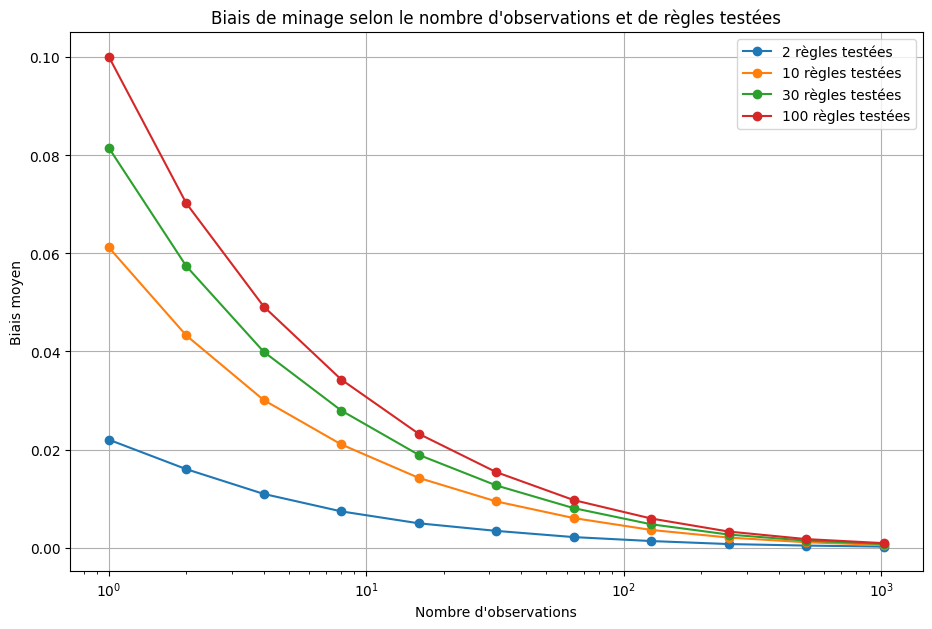

In [5]:
plt.figure(figsize=(11, 7))

for n_rules in rules_grid:
    temp = curve_summary[curve_summary["n_rules"] == n_rules]
    plt.plot(
        temp["n_observations"],
        temp["mean_bias"],
        marker="o",
        label=f"{n_rules} règles testées"
    )

plt.xscale("log")
plt.xlabel("Nombre d'observations")
plt.ylabel("Biais moyen")
plt.title("Biais de minage selon le nombre d'observations et de règles testées")
plt.legend()
plt.grid(True)
plt.show()

## 6. Interprétation EBTA

Le graphique reproduit l’intuition des figures 6.49 à 6.52 :

Quand le nombre d’observations est faible, tester beaucoup de règles est dangereux.

Avec 100 règles et très peu d’observations, il est presque certain qu’une règle paraîtra excellente uniquement par chance.

Mais quand le nombre d’observations devient élevé, les courbes se rapprochent.

Cela signifie que l’historique long compense en partie le risque lié à l’intensité du minage.

On peut résumer ainsi :

| Situation | Risque de biais | Lecture EBTA |
|---|---:|---|
| Peu d’observations, peu de règles | Moyen | Le hasard peut encore dominer |
| Peu d’observations, beaucoup de règles | Très élevé | Faux champion presque garanti |
| Beaucoup d’observations, peu de règles | Faible | Backtest plus fiable |
| Beaucoup d’observations, beaucoup de règles | Modéré à faible | Recherche intensive possible, mais à surveiller |

> Un grand nombre de règles n’est pas automatiquement fatal. Il devient fatal quand il est combiné avec un petit nombre d’observations.

## 7. Application trading : le piège du backtest court

Supposons qu’un trader teste 100 stratégies sur seulement 24 mois.

Même si la plupart des règles n’ont aucun mérite réel, l’une d’elles peut avoir eu la chance de bien tomber sur quelques mouvements de marché.

Le trader voit alors :

- un beau rendement ;
- un bon Sharpe ;
- une equity curve séduisante ;
- quelques drawdowns acceptables.

Mais en réalité, il a peut-être simplement sélectionné l’archer chanceux qui a touché le centre sur une seule flèche.

Le problème n’est pas seulement la stratégie.

Le problème est le protocole de sélection.

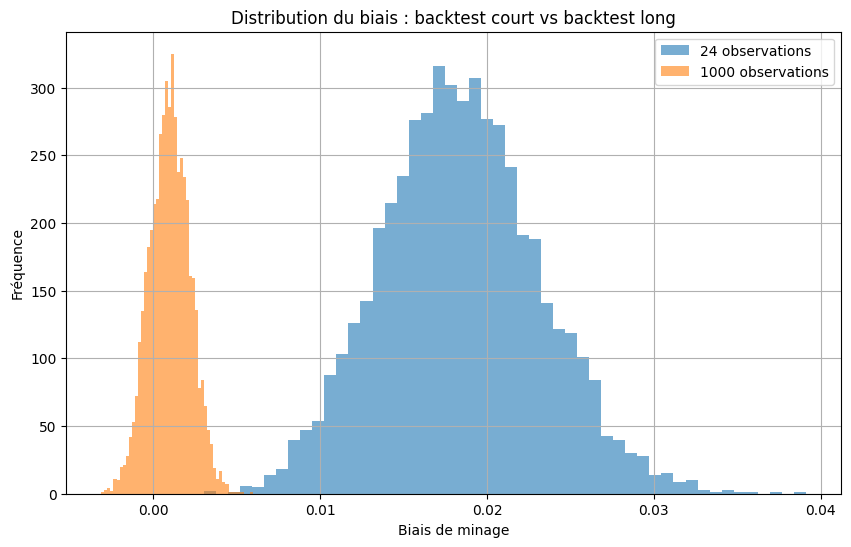

In [6]:
short_sample = simulate_data_mining_bias(
    n_observations=24,
    n_rules=100,
    n_experiments=5000
)

long_sample = simulate_data_mining_bias(
    n_observations=1000,
    n_rules=100,
    n_experiments=5000
)

plt.figure(figsize=(10, 6))

plt.hist(
    short_sample["data_mining_bias"],
    bins=50,
    alpha=0.6,
    label="24 observations"
)

plt.hist(
    long_sample["data_mining_bias"],
    bins=50,
    alpha=0.6,
    label="1000 observations"
)

plt.xlabel("Biais de minage")
plt.ylabel("Fréquence")
plt.title("Distribution du biais : backtest court vs backtest long")
plt.legend()
plt.grid(True)
plt.show()

## 8. Ce que montre l’histogramme

La distribution du biais est beaucoup plus large avec 24 observations.

Cela veut dire que les erreurs possibles sont beaucoup plus violentes.

Avec 1 000 observations, la distribution est plus serrée.

Le hasard peut encore aider une règle, mais il a beaucoup moins d’espace pour créer une hallucination statistique.

> Un backtest court ne ment pas toujours, mais il peut mentir beaucoup plus fort.

## 9. Règle pratique EBTA

Une règle simple pour ton travail de recherche quant :

| Volume de données | Nombre raisonnable d’idées à tester | Niveau de prudence |
|---:|---:|---|
| Très faible | 1 à 2 | Extrême |
| Moyen | Quelques dizaines | Fort |
| Élevé | Plusieurs dizaines à centaines | Contrôlé |
| Très élevé | Recherche intensive possible | Toujours valider hors échantillon |

Le bon réflexe n’est pas :

> Combien de stratégies puis-je tester ?

Le bon réflexe est :

> Combien d’observations indépendantes ai-je pour supporter ce volume de recherche ?

## 10. Checklist opérationnelle pour un trader EBTA

Avant de croire un backtest, pose ces questions :

- Combien d’observations indépendantes composent le test ?
- Combien de variantes ai-je réellement essayées ?
- La stratégie gagnante était-elle prévue avant le test ou découverte après plusieurs essais ?
- La performance reste-t-elle stable sur plusieurs périodes ?
- Le résultat survit-il à un test hors échantillon ?
- Le résultat survit-il à des frais, du slippage et des hypothèses réalistes ?
- L’avantage est-il expliqué par une logique de marché plausible ?

> Le nombre d’observations est le premier pare-feu contre l’illusion du trader chercheur.

## 11. L’Eurêka final

> Dans un univers de mérite variable, le but du trader quantitatif n’est pas seulement de trouver la meilleure règle observée.  
> Le vrai objectif est de s’assurer que la règle sélectionnée est meilleure parce qu’elle possède un mérite réel, et non parce qu’elle a été favorisée par un court épisode de chance.

La Loi des Grands Nombres est donc un principe de discipline.

Elle oblige le chercheur à ralentir, à tester plus longtemps, et à ne pas confondre vitesse de découverte avec robustesse scientifique.

En EBTA, un historique long n’est pas un luxe.

C’est une condition de survie.

## Annexe : texte source collé

Le texte ci-dessous est conservé comme source pédagogique d’origine.

### **CH 6 : DATA-MINING BIAS AS A FUNCTION OF NUMBER OF OBSERVATIONS: IN A UNIVERSE OF VARIABLE MERIT**

Cette section explore la relation mathématique entre le volume de données historiques utilisées (le nombre d’observations) et l’intensité du biais de minage de données dans un contexte où les règles testées ont des talents réels différents.

#### **Idées clés :**
*   **L’antidote suprême :** L’augmentation du nombre d’observations est le moyen le plus efficace pour réduire le biais de minage de données.
*   **Heed the Law of Large Numbers :** La Loi des Grands Nombres est le principe fondamental qui permet à la performance observée de converger vers la performance réelle.
*   **Déclin exponentiel du biais :** L’ampleur du mensonge statistique (le biais) chute de façon spectaculaire à mesure que l’on passe d’un échantillon très court à un échantillon de taille modérée (environ 200 mois).
*   **Compensation du risque :** Un échantillon très large (ex: 1 000 mois) permet de tester un grand nombre de règles (ex: 100) tout en maintenant un biais résiduel très faible.

#### **Référence :**
*Data-Mining Bias as a Function of Number of Observations: In a Universe of Variable Merit*, Chapitre 6, pages 314 à 316.

#### **Citation Directe :**
« The message to the data miner is clear: Heed the Law of Large Numbers. » (Page 315).

---

#### **Vision Macro :**
L'enjeu est la lutte contre la tyrannie du "bruit" temporel. David Aronson explique que le hasard est une force qui domine les échantillons restreints. En trading, un profit réalisé sur une courte période n'a quasiment aucune valeur prédictive car il est impossible de savoir s'il provient du talent ou d'une simple coïncidence avec le marché. La "vérité" d'une stratégie ne peut émerger que si elle est soumise à une multitude d'épreuves sur une longue durée. Le temps est donc le seul filtre capable de dissoudre la chance pour laisser apparaître le mérite réel.

---

#### **Vision Micro :**
Le mécanisme de réduction du biais par l'augmentation des observations repose sur la dynamique de la distribution d'échantillonnage :

1.  **Resserrement de la distribution (Figure 6.34) :** Un petit échantillon produit une distribution "large". Cela laisse beaucoup d'espace pour que le hasard génère des profits extrêmes en backtest. Un grand échantillon "écrase" cette distribution autour de la moyenne réelle, empêchant les anomalies chanceuses de survivre.
2.  **Analyse des courbes (Figures 6.49 à 6.51) :** Aronson présente trois graphiques montrant le biais en fonction du nombre de mois (de 1 à 1 024) :
    *   **Pour 2 règles :** Le biais est déjà faible et s'annule presque avec 200 observations.
    *   **Pour 100 règles :** Le biais initial est colossal sur 1 mois, mais il subit une chute brutale et se stabilise à un niveau bas une fois passé le cap des 400 à 600 observations.
3.  **L'effet de convergence (Figure 6.52) :** En superposant les courbes, on s'aperçoit que si l'échantillon est suffisamment grand (proche de 1 000 mois), la différence de biais entre tester 2 règles et en tester 100 devient négligeable. La masse de données "noie" littéralement le risque lié au nombre de tests effectués.

---

#### **Résumé Simplifié :**
Imagine que tu doives recruter un archer. Si tu ne le regardes tirer qu'une seule flèche (échantillon court), n'importe quel amateur peut toucher le centre par chance. Si tu testes 100 amateurs, l'un d'eux sera forcément "le champion" par pur hasard. Mais si tu les forces à tirer 1 000 flèches chacun (échantillon large), la chance finit par s'épuiser. Seul le vrai professionnel gardera un bon score. En trading, plus tu as d'histoire, moins tu as de chances de recruter un imposteur chanceux.

---

#### **Actions Concrètes :**
*   **Bannir les backtests courts :** Ne considérez jamais une statistique de performance (Rendement, Sharpe) calculée sur moins de quelques centaines de jours ou mois de données.
*   **Priorité à l'historique :** Avant d'ajouter des règles complexes à votre recherche, cherchez à obtenir l'historique de prix le plus profond possible.
*   **Ajuster l'ambition au volume de données :** Si vous n'avez que 2 ans de données, limitez-vous à tester 1 ou 2 idées. Si vous avez 30 ans de données, vous pouvez vous permettre de miner des centaines de règles sans exploser votre biais.

---

#### **À retenir absolument :**
*   Le nombre d'observations est le **facteur n°1** de contrôle du biais.
*   La Loi des Grands Nombres est le **seul juge de paix** du trader EBTA.
*   Le biais chute **massivement** après 200 observations.
*   Un historique long permet une **recherche plus intensive** sans perte de fiabilité.
*   La performance sur échantillon court est une **hallucination statistique**.

J'ai terminé l'analyse de la section sur le biais de minage en fonction du nombre d'observations selon le protocole EBTA.